# EE200 Course Project — Q3A: Sonic Signatures
**Mayur (Roll 240643) · Shazam-style audio fingerprinting**

We build a small song identifier: spectrogram → constellation of peaks →
combinatorial `(f1,f2,Δt)` hashes → time-offset histogram matching. Engine in
`src/q3_fingerprint.py`.

> **Data note.** This notebook uses the real song library in `data/songs/` if
> present; otherwise it auto-generates a small **synthetic demo library** so the
> pipeline runs end-to-end. The banner printed below states which case is live.
> Drop the provided songs into `data/songs/` (filenames unchanged) to run on the
> real database.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")  # silence cosmetic library notices (e.g. tqdm IProgress)
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import matplotlib.pyplot as plt
import q3_fingerprint as fp
import q3_demo_data as dd

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
DATA, FIG = os.path.join("..", "data"), os.path.join("..", "figures")
os.makedirs(FIG, exist_ok=True)
np.random.seed(0)

paths, is_real = dd.resolve_library(DATA)
print("LIBRARY:", "REAL songs from data/songs/" if is_real else "SYNTHETIC demo (data/songs_demo/)")
print("Songs:", [fp.song_label(p) for p in paths])

LIBRARY: REAL songs from data/songs/
Songs: ['A Day In The Life', 'A Hard Day_s Night', 'Across The Universe', 'Back In The U.S.S.R.', 'Blackbird', 'Bohemian Rhapsody', 'Can_t Buy Me Love', 'Crazy Little Thing Called Love', 'Day Tripper', 'Don_t Stop Me Now', 'Drive My Car', 'Eight Days A Week', 'Eleanor Rigby', 'Get Back', 'Hello, Goodbye', 'Help!', 'Helter Skelter', 'Hey Jude', 'I Am The Walrus', 'I Saw Her Standing There', 'I Want It All', 'I Want To Hold Your Hand', 'I_ll Follow The Sun', 'I_ve Got A Feeling', 'In My Life', 'Killer Queen', 'Let It Be', 'Love Me Do', 'Lucy In The Sky With Diamonds', 'Never Gonna Give You Up', 'Norwegian Wood (This Bird Has Flown)', 'Penny Lane', 'Radio Ga Ga', 'Revolution', 'Sgt. Pepper_s Lonely Hearts Club Band', 'She Said She Said', 'Somebody To Love', 'Something', 'Taxman', 'The Long And Winding Road', 'Two Of Us', 'Under Pressure', 'We Are The Champions', 'We Can Work It Out', 'We Will Rock You', 'While My Guitar Gently Weeps', 'With A Little He

## 1. Why a single Fourier transform is not enough
The DFT of an entire song tells you *which* frequencies are present but throws
away *when* they occur — all timing is gone. That is fatal for recognition,
which depends on the time–frequency pattern.

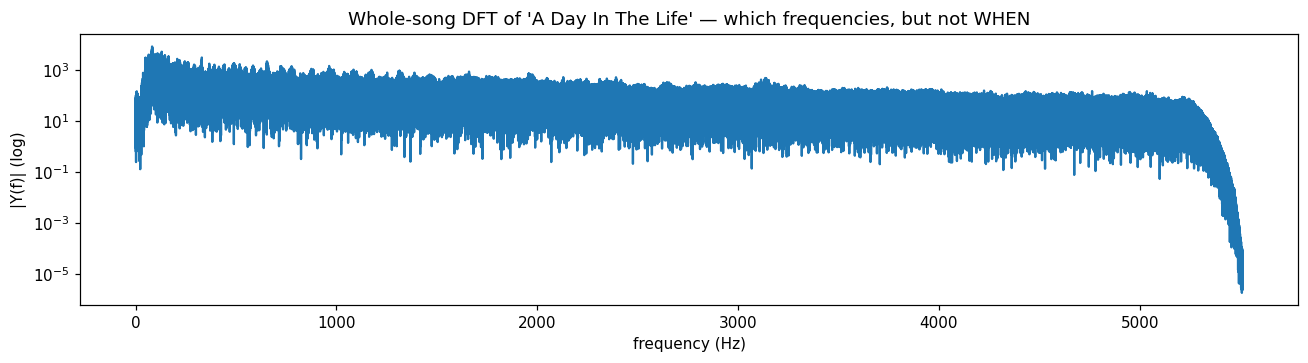

In [2]:
y0, sr = fp.load_audio(paths[0])
Y = np.abs(np.fft.rfft(y0)); freqs = np.fft.rfftfreq(y0.size, 1/sr)
plt.figure(figsize=(12, 3.4))
plt.semilogy(freqs, Y + 1e-6)
plt.xlabel("frequency (Hz)"); plt.ylabel("|Y(f)| (log)")
plt.title(f"Whole-song DFT of '{fp.song_label(paths[0])}' — which frequencies, but not WHEN")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q3_dft.png")); plt.show()

## 2. Spectrogram & the time–frequency resolution trade-off
A spectrogram slides a short window along the signal and takes the DFT of each
slice. A **short** window localizes events in time but blurs frequency; a
**long** window resolves frequency finely but smears time. This is the same
uncertainty trade-off as Q2(c)(iii).

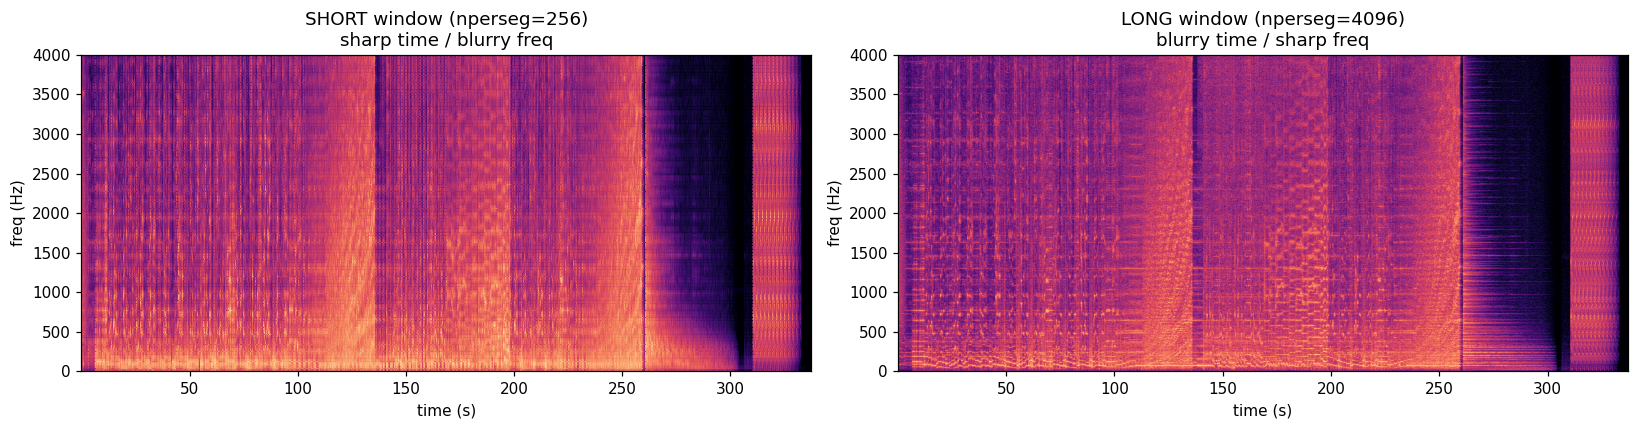

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
for a, nps, lbl in [(ax[0], 256, "SHORT window (nperseg=256)"),
                    (ax[1], 4096, "LONG window (nperseg=4096)")]:
    f, t, Sdb = fp.compute_spectrogram(y0, sr, nperseg=nps, noverlap=nps//2)
    a.pcolormesh(t, f, Sdb, shading="gouraud", cmap="magma")
    a.set_ylim(0, 4000); a.set_xlabel("time (s)"); a.set_ylabel("freq (Hz)")
    a.set_title(lbl + "\nsharp time / blurry freq" if nps==256 else lbl + "\nblurry time / sharp freq")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q3_window_tradeoff.png")); plt.show()

## 3. Constellation map — keep only the strongest peaks
We keep 2-D local maxima above an amplitude floor (`scipy.ndimage.maximum_filter`).
These sparse, high-energy points are robust to noise and form the song's
"constellation".

'A Day In The Life': 3136 peaks -> 43606 paired hashes


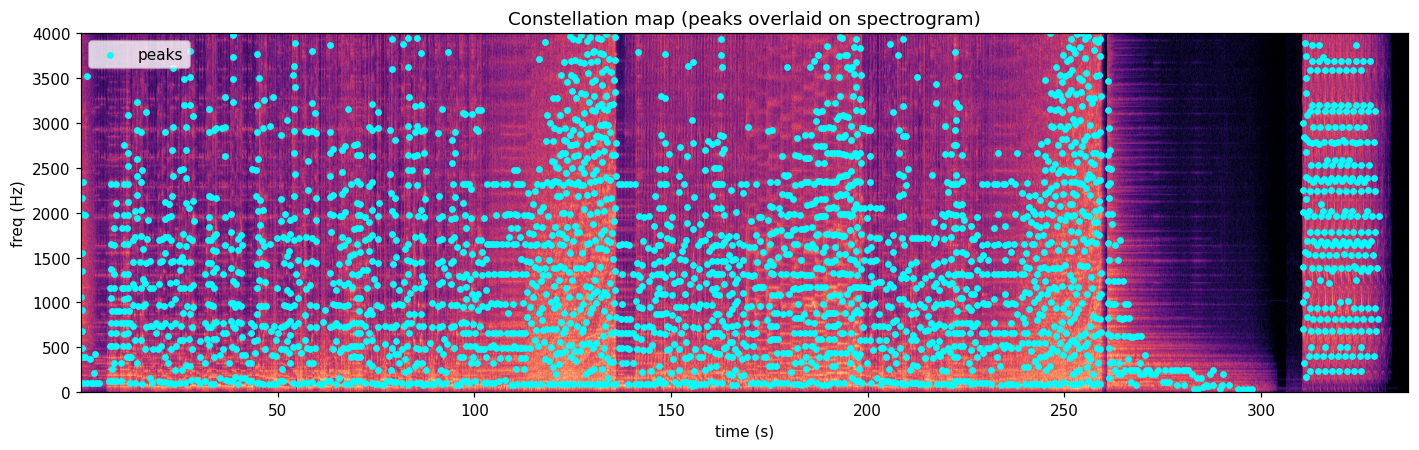

In [4]:
hashes, peaks, (f, t, Sdb) = fp.fingerprint_signal(y0, sr)
print(f"'{fp.song_label(paths[0])}': {len(peaks)} peaks -> {len(hashes)} paired hashes")
plt.figure(figsize=(13, 4.2))
plt.pcolormesh(t, f, Sdb, shading="gouraud", cmap="magma", alpha=0.9)
plt.scatter(t[peaks[:,1]], f[peaks[:,0]], s=12, c="cyan", marker="o", label="peaks")
plt.ylim(0, 4000); plt.xlabel("time (s)"); plt.ylabel("freq (Hz)")
plt.title("Constellation map (peaks overlaid on spectrogram)"); plt.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q3_constellation.png")); plt.show()

## 4. Hashing & the database
For each **anchor** peak we pair it with several peaks in a forward
time–frequency **target zone**, forming a hash key `(f1, f2, Δt)` whose value is
`(song, t_anchor)`. Pairing makes each fingerprint far more *specific* than a
lone frequency. We build one inverted index across all songs.

In [5]:
db = fp.build_database(paths)
print(f"Database: {len(db.songs)} songs, {db.num_hashes()} stored hashes, {len(db.index)} unique keys")

Database: 50 songs, 2469032 stored hashes, 1036207 unique keys


## 5. Matching — the offset histogram decides
Fingerprint the query the same way; for each song accumulate
`offset = t_db − t_query` over all matching hashes. The **true** song lines all
its hits up at a single offset (a sharp spike); a **wrong** song produces
scattered, near-uniform counts.

Query taken from 'A Hard Day_s Night'  ->  predicted 'A Hard Day_s Night'  (score=171, confidence=34.20x)


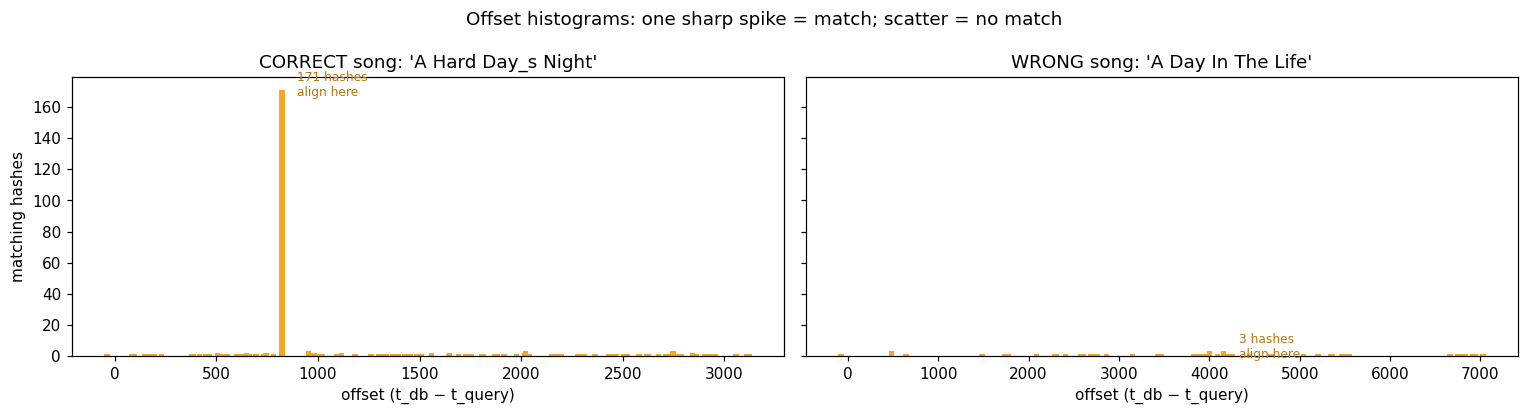

In [6]:
# Build a query clip from one song (ground truth known).
truth_path = paths[min(1, len(paths)-1)]
truth = fp.song_label(truth_path)
yq, _ = fp.load_audio(truth_path)
clip = yq[int(0.25*len(yq)): int(0.25*len(yq)) + int(4.0*sr)]
qh, qpeaks, _ = fp.fingerprint_signal(clip, sr)
best, score, conf, results = fp.identify(qh, db)
print(f"Query taken from '{truth}'  ->  predicted '{best}'  (score={score}, confidence={conf:.2f}x)")

# Offset histogram: winner vs a wrong song.
# Offsets span thousands of frames, so widen the bars (~range/120) to make the
# single-frame alignment spike clearly visible instead of a 1-px sliver.
wrong = next(s for s in db.songs if s != best)
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for a, song, ttl in [(ax[0], best, "CORRECT song"), (ax[1], wrong, "WRONG song")]:
    if song in results:
        offs = results[song][2]
        ks = np.array(list(offs.keys())); vs = np.array(list(offs.values()))
        rng = max(1, ks.max() - ks.min())
        a.bar(ks, vs, width=max(2.0, rng / 120), color="#f5a623")
        pk = ks[vs.argmax()]
        a.annotate(f"{vs.max()} hashes\nalign here", xy=(pk, vs.max()),
                   xytext=(10, -4), textcoords="offset points", fontsize=8, color="#b8780f")
    a.set_title(f"{ttl}: '{song}'"); a.set_xlabel("offset (t_db − t_query)")
ax[0].set_ylabel("matching hashes")
plt.suptitle("Offset histograms: one sharp spike = match; scatter = no match")
plt.tight_layout(); plt.savefig(os.path.join(FIG, "q3_offset_hist.png")); plt.show()

## 6. Single peaks vs paired hashes
Repeating the match using **single peak frequencies** (no pairing) gives a much
flatter, noisier histogram even for the correct song: an individual frequency
bin recurs constantly across unrelated songs, so it has low specificity. Pairing
constrains `(f1, f2, Δt)` jointly — a far rarer coincidence — which is why joined
peaks make a correct match decisive.

In [7]:
single_idx = fp.build_single_peak_index(paths)
single_res = fp.match_single_peaks(qpeaks, single_idx)
sr_rank = sorted(single_res.items(), key=lambda kv: kv[1][0], reverse=True)
pair_rank = sorted(results.items(), key=lambda kv: kv[1][0], reverse=True)

def conf_of(rank):
    if len(rank) < 2 or rank[1][1][0] == 0: return float("inf")
    return rank[0][1][0] / rank[1][1][0]
print(f"PAIRED  hashes: top='{pair_rank[0][0]}' score={pair_rank[0][1][0]}  confidence={conf_of(pair_rank):.2f}x")
print(f"SINGLE  peaks : top='{sr_rank[0][0]}' score={sr_rank[0][1][0]}  confidence={conf_of(sr_rank):.2f}x")
print("=> pairing yields a much higher winner-vs-runner-up confidence ratio (more decisive).")

PAIRED  hashes: top='A Hard Day_s Night' score=171  confidence=34.20x
SINGLE  peaks : top='A Hard Day_s Night' score=34  confidence=6.80x
=> pairing yields a much higher winner-vs-runner-up confidence ratio (more decisive).


## 7. Robustness experiments
### (a) Additive white noise — find the breakdown SNR

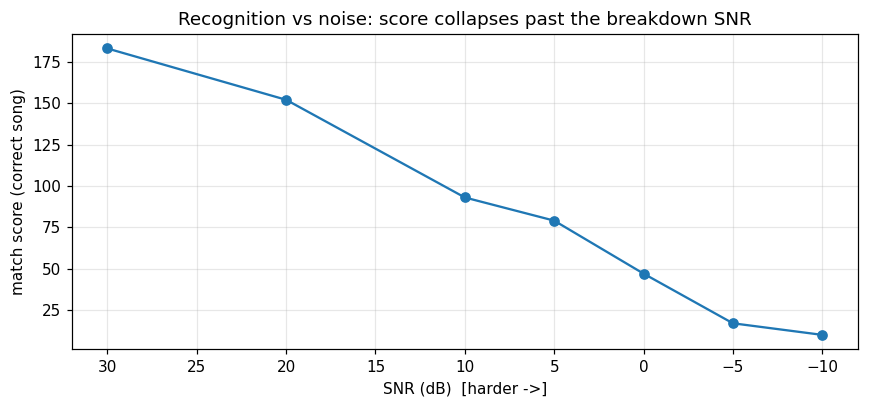

  SNR=  30 dB -> correct-song score 183
  SNR=  20 dB -> correct-song score 152
  SNR=  10 dB -> correct-song score 93
  SNR=   5 dB -> correct-song score 79
  SNR=   0 dB -> correct-song score 47
  SNR=  -5 dB -> correct-song score 17
  SNR= -10 dB -> correct-song score 10


In [8]:
snrs = [30, 20, 10, 5, 0, -5, -10]
scores, confs = [], []
for snr in snrs:
    h, _, _ = fp.fingerprint_signal(fp.add_white_noise(clip, snr, seed=0), sr)
    b, s, c, _ = fp.identify(h, db)
    scores.append(s if b == truth else 0)
    confs.append(c if (b == truth and np.isfinite(c)) else (0 if b != truth else c))
plt.figure(figsize=(8, 3.8))
plt.plot(snrs, scores, "o-")
plt.gca().invert_xaxis()
plt.xlabel("SNR (dB)  [harder ->]"); plt.ylabel("match score (correct song)")
plt.title("Recognition vs noise: score collapses past the breakdown SNR")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(FIG, "q3_noise_robustness.png")); plt.show()
for snr, s in zip(snrs, scores): print(f"  SNR={snr:>4} dB -> correct-song score {s}")

### (b) Pitch shift / time stretch — and why a tiny shift defeats it

In [9]:
for semis in [0.0, 0.5, 1.0, 2.0]:
    sig = clip if semis == 0 else fp.pitch_shift(clip, sr, semis)
    h, _, _ = fp.fingerprint_signal(sig, sr)
    b, s, c, _ = fp.identify(h, db)
    print(f"  pitch shift {semis:>3} semitone(s) -> predicted '{b}' (score={s})  {'OK' if b==truth else 'FAILED'}")

  pitch shift 0.0 semitone(s) -> predicted 'A Hard Day_s Night' (score=171)  OK


  pitch shift 0.5 semitone(s) -> predicted 'Radio Ga Ga' (score=4)  FAILED
  pitch shift 1.0 semitone(s) -> predicted 'Back In The U.S.S.R.' (score=5)  FAILED
  pitch shift 2.0 semitone(s) -> predicted 'Taxman' (score=6)  FAILED


**Why a small pitch shift breaks it.** The hash keys store **absolute frequency
bins**. A pitch shift multiplies every frequency by a constant, so every peak
moves to a different bin and essentially **no hash collides** with the database
— even though a human ear, which tracks *relative* pitch, hears the same song.

**One concrete fix.** Quantize peaks to **log-frequency / constant-Q** bins (a
pitch shift becomes a constant *additive* offset there, easier to tolerate), or
allow a small ± tolerance in hash lookup, or pre-index a few pitch-shifted copies
of each song offline.

---
## Q3A — Summary
A single DFT loses timing; the spectrogram restores it with a tunable
time–frequency trade-off. Sparse peak constellations + combinatorial
`(f1,f2,Δt)` hashes give a specific, noise-robust fingerprint; the time-offset
histogram turns hash hits into a single decisive alignment spike for the true
song. Pairing beats single peaks on specificity. The system tolerates heavy
additive noise but is defeated by small pitch shifts because it keys on absolute
frequency — fixable with log-frequency/constant-Q hashing.